In [5]:
import pandas as pd
import numpy as np
import sys
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.metrics.fidelity.PairwiseSimilarity import PairwiseSimilarity
from SynOmics.processing.metadata import MetaData
from SynOmics.processing.postprocessing import post_masking

or_data = pd.read_csv("Data/original_data.csv", index_col = 0)
clinical_or_data = or_data.iloc[:,59:200]
# masked_clinical_or_data = post_masking(clinical_or_data)

# ordinal_cat_columns = ["MSKCC", "Number_of_Prior_Therapies", "ORR","ExtremeResponder","Benefit"]
metadata = MetaData.get_metadata(data = clinical_or_data, 
                                 threshold_unique_values = 10, 
                                    ordinal_features = None)
seeds = [42,0,1]
# syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]

In [2]:
from typing import Dict, Optional, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from scipy import stats
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl


def plot_violin_with_pvalue_heatmap(
    scores_dict: Dict[str, np.ndarray],
    title: Optional[str] = None,
    figsize: Tuple[int, int] = (14, 6),
    order: Optional[list] = None,
    palette='Set2',
    alpha: float = 0.05,
    cmap_green: str = 'Greens',
    pink_color: str = '#ffd6e0',
    white_color: Tuple[float, float, float] = (1.0, 1.0, 1.0),
    test: str = 'ranksums',
    annotate: bool = True,
    adjusted: bool = True,
    fontsize: int = 11,
):
    # Basic validation
    if not scores_dict or len(scores_dict) < 2:
        raise ValueError("scores_dict must contain at least two groups to compare.")

    methods = list(scores_dict.keys()) if order is None else order
    missing = [m for m in methods if m not in scores_dict]
    if missing:
        raise ValueError(f"The following methods specified in order are missing from scores_dict: {missing}")

    # Build DataFrame for plotting (drop NaNs)
    records = []
    for m in methods:
        arr = np.asarray(scores_dict[m])
        arr = arr[~np.isnan(arr)]
        for v in arr:
            records.append((m, float(v)))
    df = pd.DataFrame(records, columns=['method', 'score'])
    if df.empty:
        raise ValueError("After removing NaNs, no data remains to plot.")

    # Compute pairwise p-values using Wilcoxon rank-sum (ranksums)
    n = len(methods)
    pmat = pd.DataFrame(np.ones((n, n)), index=methods, columns=methods, dtype=float)
    statmat = pd.DataFrame(np.nan, index=methods, columns=methods, dtype=float)

    for i, j in itertools.combinations(range(n), 2):
        m1 = methods[i]
        m2 = methods[j]
        a = df.loc[df['method'] == m1, 'score'].values
        b = df.loc[df['method'] == m2, 'score'].values

        if len(a) < 2 or len(b) < 2:
            stat, p = np.nan, np.nan
        else:
            if test == 'ranksums':
                stat, p = stats.ranksums(a, b)
            else:
                raise ValueError("Unsupported test. Only 'ranksums' supported in this function.")
        pmat.loc[m1, m2] = pmat.loc[m2, m1] = p
        statmat.loc[m1, m2] = statmat.loc[m2, m1] = stat

    # Diagonal set to 0 for convenience (not used for significance)
    np.fill_diagonal(pmat.values, 0.0)
    np.fill_diagonal(statmat.values, 0.0)

    # If requested, adjust p-values for multiple testing (Benjamini-Hochberg FDR)
    pmat_used = pmat.copy()
    if adjusted:
        try:
            from statsmodels.stats.multitest import multipletests
        except ImportError as e:
            raise ImportError("statsmodels is required to adjust p-values. Install it (pip install statsmodels).") from e

        # collect upper triangle p-values (i < j)
        idx_pairs = []
        pvals = []
        for i in range(n):
            for j in range(i + 1, n):
                p = pmat.iat[i, j]
                if np.isnan(p):
                    p = 1.0
                pvals.append(p)
                idx_pairs.append((i, j))

        if len(pvals) > 0:
            rej, pvals_adj, _, _ = multipletests(pvals, alpha=alpha, method='fdr_bh')
            # build adjusted p-value DataFrame (symmetric)
            pmat_adj = pd.DataFrame(np.ones((n, n)), index=methods, columns=methods, dtype=float)
            for (i, j), padj in zip(idx_pairs, pvals_adj):
                pmat_adj.iat[i, j] = pmat_adj.iat[j, i] = padj
            np.fill_diagonal(pmat_adj.values, 0.0)
            pmat_used = pmat_adj
        else:
            # nothing to adjust; keep raw
            pmat_used = pmat.copy()


    eps = 1e-300
    p_clipped = pmat_used.copy().replace(0.0, np.nan)  # keep diagonal as nan for now in clipping
    p_clipped = p_clipped.fillna(1.0)
    # compute -log10(p) matrix
    with np.errstate(divide='ignore'):
        logp = -np.log10(p_clipped.clip(eps, 1.0))
    # determine scale for shading greens: compute threshold logp for alpha
    logp_threshold = -np.log10(max(alpha, eps))
    # find maximum logp among significant cells to normalize; set a lower bound
    sig_logp_vals = logp.values.flatten()
    sig_logp_vals = sig_logp_vals[~np.isnan(sig_logp_vals)]
    # only consider values > logp_threshold (i.e., p < alpha)
    sig_logp_vals = sig_logp_vals[sig_logp_vals > logp_threshold]
    if sig_logp_vals.size > 0:
        logp_max = float(np.nanmax(sig_logp_vals))
    else:
        # set a reasonable default to avoid division by zero
        logp_max = logp_threshold + 1.0

    # Prepare colormap and color constants
    cmap = cm.get_cmap(cmap_green)
    pink_rgba = mcolors.to_rgba(pink_color)
    white_rgba = mcolors.to_rgba(white_color)

    rgba_array = np.zeros((n, n, 4), dtype=float)
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            if i == j:
                rgba_array[i, j, :] = white_rgba
                continue
            p = pmat_used.loc[m1, m2]
            if np.isnan(p) or p >= alpha:
                rgba_array[i, j, :] = pink_rgba
            else:
                # significant: compute normalized intensity between 0 and 1
                val = -np.log10(max(p, eps))
                # map val from [logp_threshold, logp_max] -> [0,1]
                if logp_max - logp_threshold <= 0:
                    norm = 1.0
                else:
                    norm = (val - logp_threshold) / (logp_max - logp_threshold)
                    norm = np.clip(norm, 0.0, 1.0)
                # use cmap to get green shade; shift to use darker colors for higher norm
                rgba = cmap(0.2 + 0.8 * norm)  # avoid the very lightest greens (start at 0.2)
                rgba_array[i, j, :] = rgba

    # Plotting
    sns.set(style="whitegrid", rc={'axes.facecolor': (0.98, 0.98, 0.99)})
    pal = palette if (isinstance(palette, (list, tuple)) and len(palette) >= n) else sns.color_palette(palette, n_colors=n)

    fig = plt.figure(figsize=figsize)
    # Create gridspec with two panels: violin (left, larger) and heatmap (right)
    gs = fig.add_gridspec(nrows=1, ncols=10, width_ratios=[6, 0.2, 3, 0.2, 0.8, 0.0, 0.0, 0.0, 0.0, 0.0], wspace=0.8)
    ax_violin = fig.add_subplot(gs[0, 0])
    ax_heatmap = fig.add_subplot(gs[0, 2])

    # Violin plot
    sns.violinplot(
        x='method',
        y='score',
        data=df,
        order=methods,
        palette=pal,
        cut=0,
        inner='quartile',
        linewidth=1.2,
        ax=ax_violin
    )

    # Compute and plot means
    means = df.groupby('method')['score'].mean().reindex(methods)
    ylim = ax_violin.get_ylim()
    yspan = ylim[1] - ylim[0] if (ylim[1] - ylim[0]) != 0 else 1.0
    for i, m in enumerate(methods):
        mean_val = means.loc[m]
        # white diamond with black edge
        ax_violin.scatter(i, mean_val, color='white', edgecolor='black', s=80, zorder=10, linewidth=1.1, marker='D')
        if annotate:
            ax_violin.text(i, mean_val + yspan * 0.03, f"{mean_val:.3f}",
                           ha='center', va='bottom', fontsize=fontsize - 1, color='black')

    ax_violin.set_xlabel('')
    ax_violin.set_ylabel('Score', fontsize=fontsize)
    ax_violin.tick_params(axis='x', labelsize=fontsize - 1, rotation=90)
    ax_violin.tick_params(axis='y', labelsize=fontsize - 1)
    if title:
        ax_violin.set_title(title, fontsize=fontsize + 1, fontweight='bold')
    else:
        ax_violin.set_title('Distribution of scores by method\n(mean shown as white diamond)', fontsize=fontsize + 1, fontweight='bold')
    # sns.despine(trim=True, ax=ax_violin)

    # Heatmap: display the RGBA array. We flip vertically so that first method is on top (matching DataFrame order)
    ax_heatmap.imshow(rgba_array, aspect='equal', interpolation='nearest', origin='upper')
    ax_heatmap.set_xticks(np.arange(n))
    ax_heatmap.set_yticks(np.arange(n))
    ax_heatmap.set_xticklabels(methods, rotation=45, ha='right', fontsize=fontsize - 1)
    ax_heatmap.set_yticklabels(methods, fontsize=fontsize - 1)
    ax_heatmap.set_title('Pairwise significance\n(white: diagonal, pink: n.s., green: significant)', fontsize=fontsize - 1)
    # gridlines between cells for clarity (disabled by default)
    # ax_heatmap.set_xticks(np.arange(-0.5, n, 1), minor=True)
    # ax_heatmap.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax_heatmap.grid(False)
    ax_heatmap.tick_params(which='minor', bottom=False, left=False)

    # Add colorbar that corresponds to green intensity only (i.e. -log10(p) for significant cells).
    # Build a ScalarMappable that maps [logp_threshold, logp_max] to greens colormap range [0.2..1]
    import matplotlib as mpl
    norm = mpl.colors.Normalize(vmin=logp_threshold, vmax=max(logp_threshold + 1e-6, logp_max))
    # create a new cmap that matches the segment we used (0.2..1 of the chosen cmap)
    # build a ListedColormap by sampling
    sample_vals = np.linspace(0.2, 1.0, 256)
    sampled_colors = cmap(sample_vals)
    sampled_cmap = mpl.colors.ListedColormap(sampled_colors)
    sm = mpl.cm.ScalarMappable(cmap=sampled_cmap, norm=norm)
    sm.set_array([])  # for colorbar
    cbar = fig.colorbar(sm, ax=ax_heatmap, fraction=0.046, pad=0.04)
    cbar.set_label('-log10(p) (only significant cells)', fontsize=fontsize - 1)
    # We keep colorbar ticks readable
    cbar_ticks = np.linspace(logp_threshold, max(logp_threshold, logp_max), num=4)
    cbar.set_ticks(cbar_ticks)
    cbar.set_ticklabels([f"{t:.1f}" for t in cbar_ticks])

    plt.tight_layout()
    return fig, (ax_violin, ax_heatmap), pmat_used

---Seed 42---
---Method avatarsk5_42---
--- System & Process Info ---
Current Date and Time (UTC): 2025-11-14 22:42:13
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 32
Logical Processors: 32
Process RAM before execution: 994.43 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'nvidia-ml-py' is installed and NVIDIA drivers are accessible.
Error: module 'nvidia_smi' has no attribute 'nvidia_smi_lib'

--- Function Execution ---
Processing data
Calculating correlation matrix for both original data and synthetic data. This matrix is mixed between spearman correlation and Cramér's V.

Summary of Pairwise score:
Summary of Pairwise Score Matrix:
  Number of elements: 9870
  Min value: 0.6548
  Max value: 1.0000
  Mean: 0.9563
  Median: 0.9664
  Standard deviation: 0.0401

--- Resource Usage Summary ---
Execution time: 2.155775 seconds
Process RAM after execution: 994.44 MB
Process RAM used by function: 0.01 MB
Average per-core CPU during execution: [4.2, 21.9, 5.1, 6.9, 4.

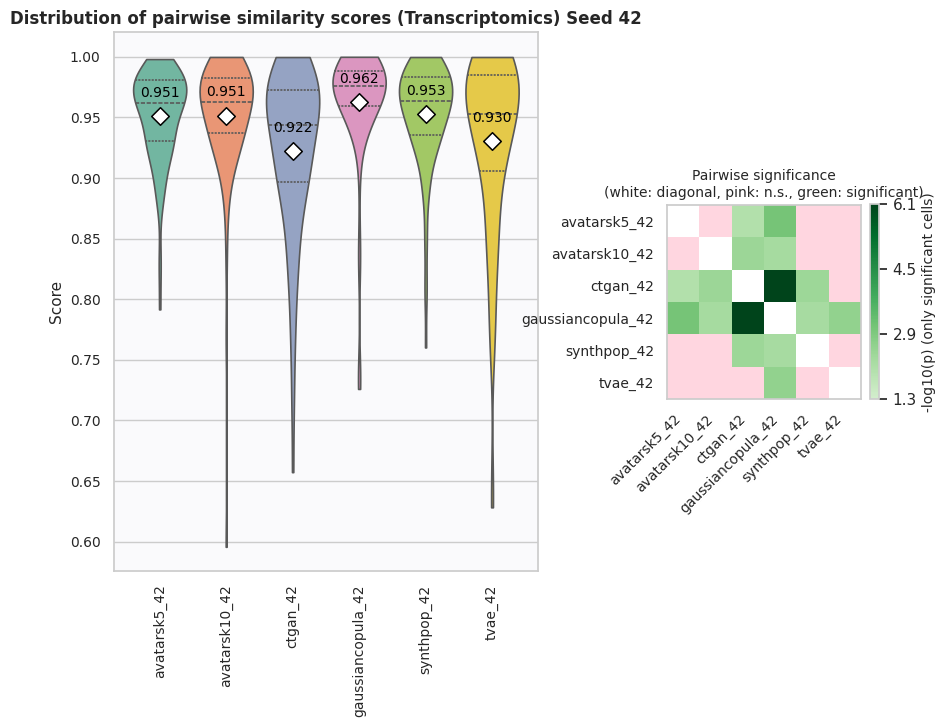

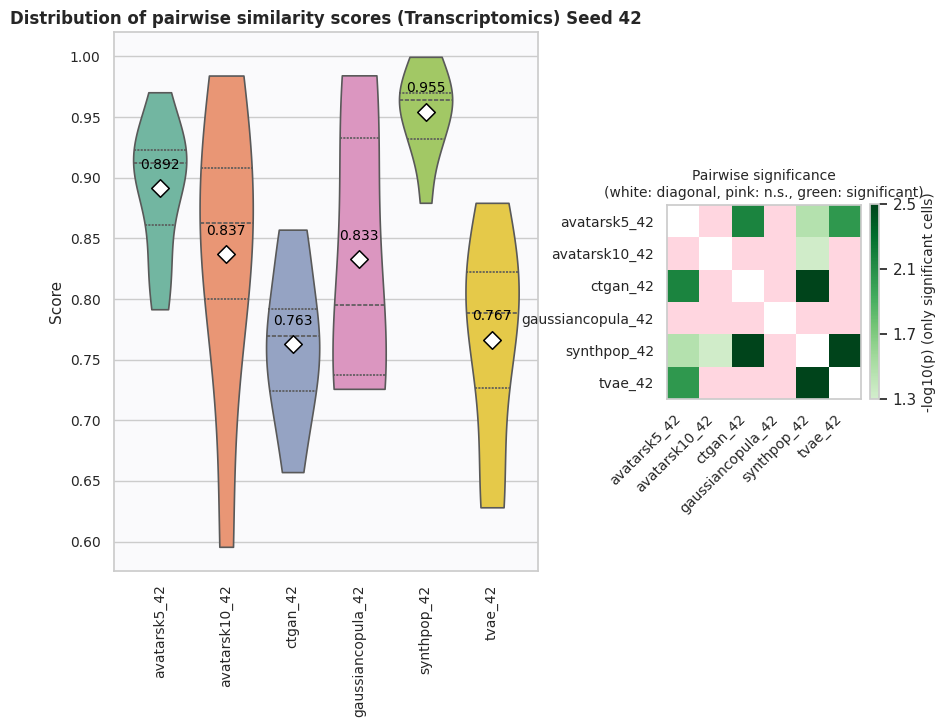

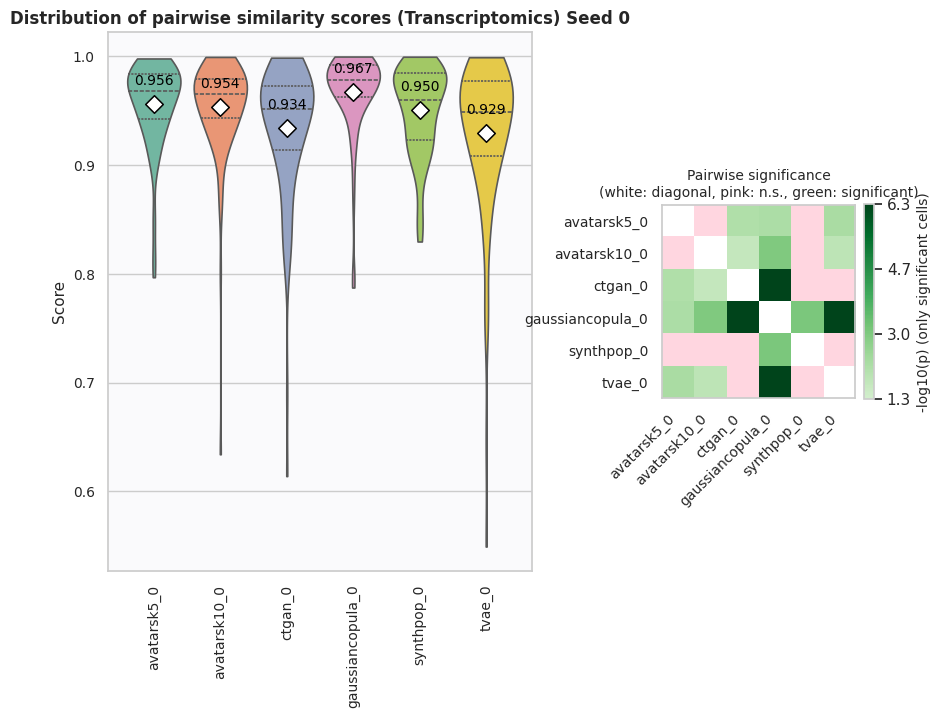

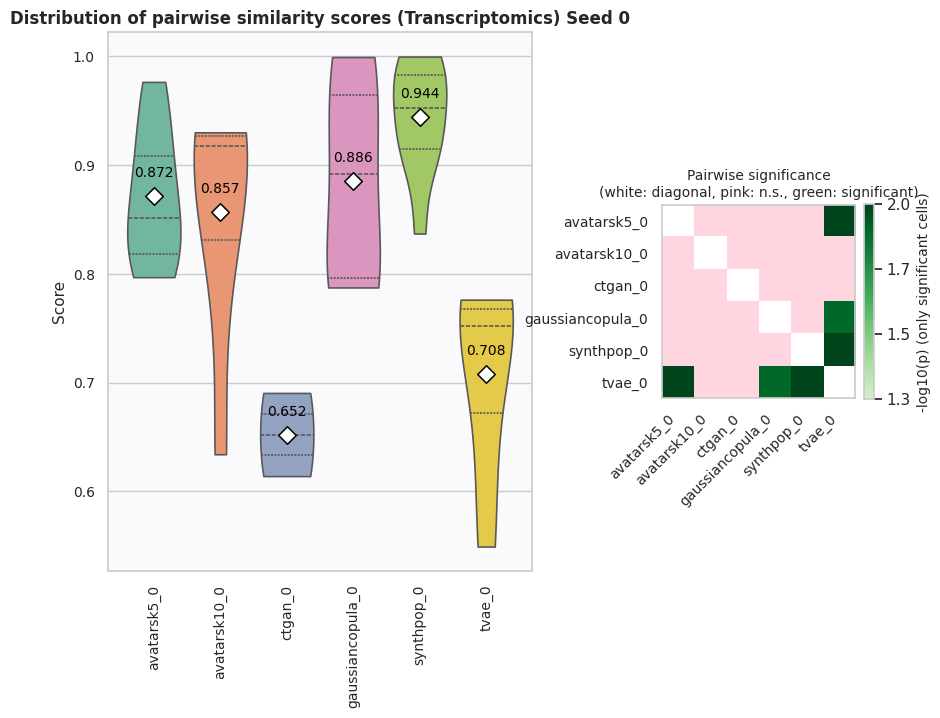

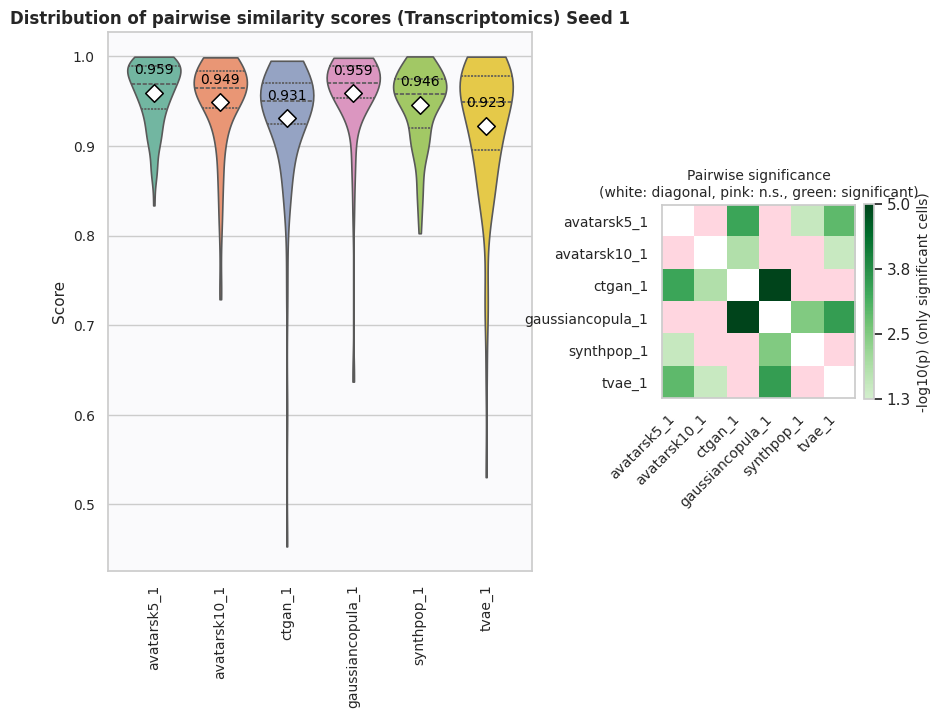

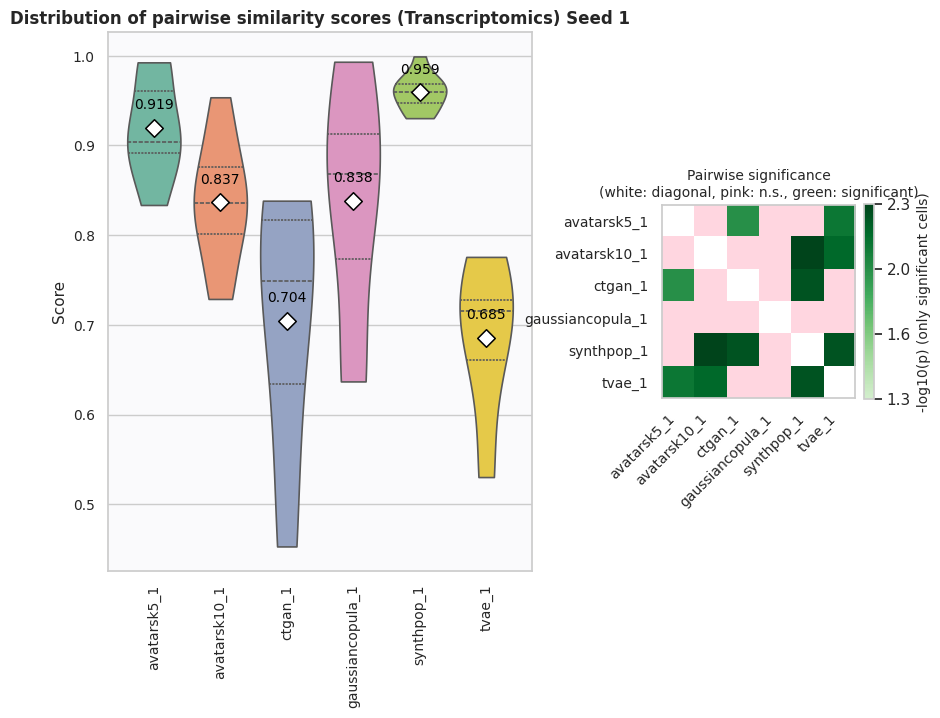

In [10]:
results_all = {}
n = int(100)
rng = default_rng(42) 
for seed in seeds:
    print(f"---Seed {seed}---")
    syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
    results_seed = {}
    visulize_results_dict = {}
    visulize_results_dict_filtered = {}
    for syn_data in syn_datas:
        print(f"---Method {syn_data}---")
        syn_df = pd.read_csv(f"Data/{syn_data}.csv", index_col = 0)
        clinical_syn_df = syn_df.iloc[:,59:200]
        # masked_syn_clinical_df = post_masking(clinical_syn_df)
        pw_computer = PairwiseSimilarity(
        original_data = clinical_or_data,
        synthetic_data = clinical_syn_df,
        metadata = metadata,
        output_dir = f"PairwiseTranscriptomicsSimi/PairwiseTranscriptomicsSimi_{seed}",
        verbose = True,
        save = True,
        name = syn_data
    )
        result = pw_computer.get_pairwise_scores(method = "spearman")
        results_seed[syn_data] =result
        correlations_scores = result["PairwiseScore"]
        or_correlations = result["OriginalCorrelation"]
        indices = rng.choice(correlations_scores.shape[0], size=n, replace=False)
        sampling_scores = correlations_scores[indices]
        sampling_or_correlations = or_correlations[indices]
        filtered_indices =  np.where(np.absolute(sampling_or_correlations) > 0.4)[0]
        chosing_scores = sampling_scores[filtered_indices]
        visulize_results_dict[syn_data] = sampling_scores
        visulize_results_dict_filtered[syn_data] = chosing_scores
    title_sampling = f'Distribution of pairwise similarity scores (Transcriptomics) Seed {seed}'
    fig_sampling, (ax_v, ax_h), pvals = plot_violin_with_pvalue_heatmap(visulize_results_dict, title = title_sampling,
                                                           figsize=(16, 7), adjusted=True)
    fig_sampling.savefig(f"PairwiseTranscriptomicsSimi/PairwiseTranscriptomicsSimi_{seed}/Benchmark_Paiwise_Transcriptomics.png", dpi=300, bbox_inches='tight')

    title_filtered = f'Distribution of pairwise similarity scores (Transcriptomics) Seed {seed}'
    fig_filtered, (ax_v, ax_h), pvals = plot_violin_with_pvalue_heatmap(visulize_results_dict_filtered, title = title_filtered,
                                                           figsize=(16, 7), adjusted=True)
    fig_filtered.savefig(f"PairwiseTranscriptomicsSimi/PairwiseTranscriptomicsSimi_{seed}/Benchmark_Paiwise_Transcriptomics_Filter.png", dpi=300, bbox_inches='tight')